# Stat 220, Unit 3 Homework: Linear Regression

`housing_data.csv` is 1,000 home sales with `house_price`, `square_footage`,
`num_bedrooms`, `has_garage` (1 or 0), and `neighborhood`.

```python
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

rng = np.random.default_rng(220)
homes = pd.read_csv("https://richardson.byu.edu/220/housing_data.csv")
homes.head()
```

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

rng = np.random.default_rng(220)
homes = pd.read_csv("https://richardson.byu.edu/220/housing_data.csv")
homes.head()

,house_price,square_footage,num_bedrooms,has_garage,neighborhood
0,492000,1699.053577,4,1,Downtown
1,362300,1503.150704,2,1,Suburb
2,604100,2513.392528,4,1,Suburb
3,529400,2375.530651,2,1,Suburb
4,432300,1245.416731,3,1,Beachside


**Problem 1.** *A slope you already know the answer to.* You set the truth, then see what the
regression reports back.

Part a. Run this. The true slope is 1.5. Report the estimate and its 95% interval, and say whether the interval covers the truth.

In [3]:
n = 200
x = rng.normal(0, 1, n)
y = 3 + 1.5*x + rng.normal(0, 2, n)

fit = smf.ols("y ~ x", data=pd.DataFrame({"x": x, "y": y})).fit()
print(f"estimated slope : {fit.params['x']:.3f}")
print(f"standard error  : {fit.bse['x']:.3f}")
print("95% interval    :", fit.conf_int().loc["x"].round(3).tolist())

estimated slope : 1.771
standard error  : 0.142
95% interval    : [1.491, 2.05]


_Your answer:_

The interval does cover the true slope
CI: [1.491, 2.05]



Part b. This repeats that study 500 times. Compare the spread of the 500 estimates to the standard error one study reported in part a, and say what a standard error is measuring.

In [4]:
slopes = []
for _ in range(500):
    xs = rng.normal(0, 1, n)
    ys = 3 + 1.5*xs + rng.normal(0, 2, n)
    slopes.append(smf.ols("y ~ x", data=pd.DataFrame({"x": xs, "y": ys})).fit().params["x"])

print(f"mean of the 500 estimates : {np.mean(slopes):.3f}")
print(f"SD of the 500 estimates   : {np.std(slopes):.3f}")

mean of the 500 estimates : 1.497
SD of the 500 estimates   : 0.143


_Your answer:_

Standard error measure the difference between the sample estimate and the true mean, or how much the slope changes as more sample is gathered. The Standard Error from the 500 estimates and the single sample from problem 1.a) is almost the same.



Part c. In part b the estimates are centered on 1.5 but individually off by a fair amount. A classmate says the regression is therefore unreliable. Answer them in two or three sentences.



_Your answer:_

Though the estimates individually may seem off, in problem 1.a) the standard error is 0.142, which is almost the same as the SD of the 500 estimates (0.143). The SE measures how much the slope changes as more estimates are gathered, and when that was put to test in calculating the variance of 500 estimates, the numbers matched. This means that the variation of the means are normal for this regression, and align with the predictions, so it's a reliable model. Also, the student said that it's off by a 'fair' amount, which is not a precise error.


**Problem 2.** *What is a square foot worth?* A homeowner is deciding whether to add 400 square
feet and wants a number.

Part a. Fit `house_price` on `square_footage` and report the slope with its units and its 95% confidence interval. (`smf.ols("house_price ~ square_footage", data=homes).fit()`, then `.conf_int()`.)

In [5]:
homes['square_footage'].max()

np.float64(3215.1133261722543)

In [7]:
smf.ols("house_price ~ square_footage", data=homes).fit().conf_int()

,0,1
Intercept,85185.627389,157625.598969
square_footage,162.385625,198.013984


Slope 95% CI: [162.34 ft, 198.01 ft]

Part b. Write the one sentence you would tell the homeowner, including the units and the range of sizes the data actually covers.

_Your answer:_

For every square footage increase, the house price is associated to increase between $162 and $198.

Part c. Here is what the model missed. Say whether you see a pattern, and what that means for trusting the line.

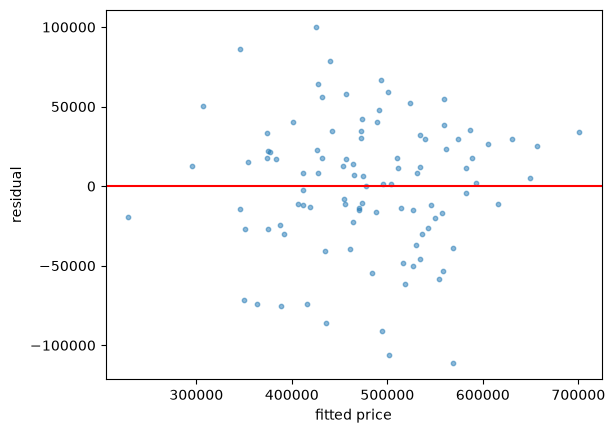

R-squared   : 0.804
residual SD : 41,923 dollars


In [8]:
fit2 = smf.ols("house_price ~ square_footage", data=homes).fit()
plt.scatter(fit2.fittedvalues, fit2.resid, s=10, alpha=0.5)
plt.axhline(0, color="red"); plt.xlabel("fitted price"); plt.ylabel("residual"); plt.show()

print(f"R-squared   : {fit2.rsquared:.3f}")
print(f"residual SD : {np.sqrt(fit2.scale):,.0f} dollars")

_Your answer:_

Because the dots are located like a cloud around the 0 red line with no correlation, no clear pattern, no curve in the residual plot, and the vertical spread remains even across fitted values. These are all signs that the model is giving an average trend and behaving as expected.

Part d. The homeowner asks for the predicted price of a 6,000 square foot house. Look at the range in your part a answer and say, in two or three sentences, what you would tell them.

_Your answer:_

The problem with predicting a 6000 sqft house is that you can put that in the equation of intercept and slope and get a value (around $1,057,186), however the data's max square footage is 3215 sqft. This means that predicting a 6000 house is extrapolation, and we don't know how the house price will act with square footage that high because we don't have data for that. 

**Problem 3.** *Adding a category.* The same homes, now with a garage and a neighborhood.

Part a. Report the coefficient on `has_garage` and write the sentence that interprets it. Say exactly what is being held fixed.

In [9]:
g = smf.ols("house_price ~ square_footage + has_garage", data=homes).fit()
print(g.params.round(1))
print("\n95% interval on has_garage:", g.conf_int().loc["has_garage"].round(0).tolist())

Intercept         113954.5
square_footage       177.2
has_garage         23461.9
dtype: float64

95% interval on has_garage: [7115.0, 39808.0]


_Your answer:_

The coefficient for has_garage is 23461.9, this means that holding all else constant, the house price increases by about $23461.90 because it has a garage. Intercept and square_footage is what is being held constant. 


Part b. `neighborhood` has several levels. Name the baseline level, and explain how to read one of the other coefficients.

In [10]:
nb_fit = smf.ols("house_price ~ square_footage + C(neighborhood)", data=homes).fit()
print(nb_fit.params.round(1))
print("\nlevels in the data:", sorted(homes.neighborhood.unique()))

Intercept                         147830.5
C(neighborhood)[T.Countryside]    -64505.7
C(neighborhood)[T.Downtown]       -22807.4
C(neighborhood)[T.Suburb]         -42423.5
square_footage                       184.5
dtype: float64

levels in the data: ['Beachside', 'Countryside', 'Downtown', 'Suburb']


_Your answer:_

Beachside is the baseline level because when Countryside, Downtown, Suburb are 0, there is only Beachside left. If I want to see the house price prediction for a house that is downtown, Countryside, and Suburb would be 0 and Downtown would be 1. According to these coefficients, the house price decreases by -$22807.40 if the house is in Downtown.


Part c. A realtor asks what a garage is worth. Answer in two or three sentences, using the number, its uncertainty, and the homes it applies to.

_Your answer:_

A garage's worth is $23461.90 because it increases the house price by about that amount. Its increase is between $7115.00 and $39808.00 with a 95% CI. This applies to the range of houses in our dataset, and reflects an association, not a causal effect of adding a garage.

**Problem 4.** *A coefficient that changes its mind.* Does an extra bedroom raise the price?

Part a. Report the bedroom coefficient from each model and say how much of the first one survived.

In [11]:
alone = smf.ols("house_price ~ num_bedrooms", data=homes).fit()
with_size = smf.ols("house_price ~ num_bedrooms + square_footage", data=homes).fit()

print(f"bedrooms alone          : {alone.params['num_bedrooms']:+,.0f} dollars per bedroom")
print(f"bedrooms, with size in  : {with_size.params['num_bedrooms']:+,.0f} dollars per bedroom")
print(f"\ncorr(bedrooms, square footage) = "
      f"{homes.num_bedrooms.corr(homes.square_footage):+.2f}")

bedrooms alone          : +52,814 dollars per bedroom
bedrooms, with size in  : +23,499 dollars per bedroom

corr(bedrooms, square footage) = +0.42


_Your answer:_

The coefficient between bedrooms and house price is $52814 per bedroom. After adding the square footage feature, this coefficient decreases to $23499. This is a difference of $29315, which means that in the originial coefficient, the $29315 value was actually just a house-size effect in disguise. This is confirmed as we see the positive correlation between bedrooms, and squarefootage. In the original coefficient the size wasn't taken into account, so it was disguised in the bedrooms feature.

Part b. Explain the mechanism in two or three sentences: why does leaving square footage out change the bedroom coefficient?

_Your answer:_

The change in house price involves more features than just the amount of bedrooms. However, when taking the coefficient of only the bedroom, the significance of the other features are disguised inside the bedroom coefficient. When more features are taking into consideration, is clear to see which feature has more correlation, where amount of bedrooms has a lesser correlation than square footage. 

Part c. A builder asks whether splitting the same floor space into more bedrooms would raise the price. Which of the two numbers is closer to an answer for them, and what would still worry you?

_Your answer:_

The number that is closer to this answer is the coefficient of the bedrooms with size in, whicih would be 23499. This means that when keeping the square footage constant, increasing bedrooms would increase house price by about $23499. 
What worries me is that there are other factors we should consider than only square footage. There could be other features like has_garage, neighborhood, etc. that could also decrease the bedroom coefficient, and show that adding more bedrooms may not increase house price as much. 

**Problem 5.** *What can and cannot be said.* No computer.

Part a. For your Problem 2 square footage slope, write one claim the analysis supports and one that sounds similar but it does not. Say what separates them.

_Your answer:_

Supported Claim: According to the dataset, for every square footage increase, the house price is expected to increase between $162-$198 (95% CI).
Unsupported Claim: House price will increase by $162-$198 as square footage increases.

The supported claim is an association and the unsupported claim a causal effect. The house price is not going to automatically increase by $162-$198 as the square footage. This also means that the behaviour of square footage outside of the dataset (1000-3200 sq ft) could be different than what's observed in the dataset (extrapolation). 


Part b. Does the neighborhood coefficient in Problem 3 tell you what would happen to a house's price if you picked it up and moved it to that neighborhood? Explain.

_Your answer:_

No it does not. The neighborhood coefficient is an association between house prices and neighborhood, and not a causal effect. Neighborhoods differ in unobserved ways, school district, house age, etc. so the same coefficient won't automatically apply. Moving a house to a specific neighborhood could or could not impact the house price. Predictions and assumptions can be maded based on the coefficient, but it does not represent a certainty.

Part c. A colleague summarizes the assignment as "we found that square footage causes price to rise, garages add value, and bedrooms do not matter." Rewrite it so every claim is one your analyses support.

_Your answer:_

We found that square footage is associated with House Price increase of about $162-$198, houses with a garage sell for about $23461.90 more on average (holding size constant), and an extra bedroom is associated with a $23,499 higher price when square footage is constant.